In [ ]:
!pip install datasets transformers torch sentence-transformers faiss-cpu matplotlib seaborn scikit-learn tqdm openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 61.6 MB/s eta 0:00:00


Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

Building index...
Building FAISS index...


Processing samples: 100%|██████████| 10000/10000 [00:01<00:00, 7834.41it/s]


Index built with 10000 documents
Evaluating system...
Evaluating RAG system...


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Evaluating: 100%|██████████| 200/200 [12:42<00:00,  3.81s/it]


Calculating metrics...

RAG SYSTEM EVALUATION RESULTS
Accuracy: 0.835
Precision: 0.851
Recall: 0.835
F1 Score: 0.833
Samples evaluated: 200/200
Generating plots...


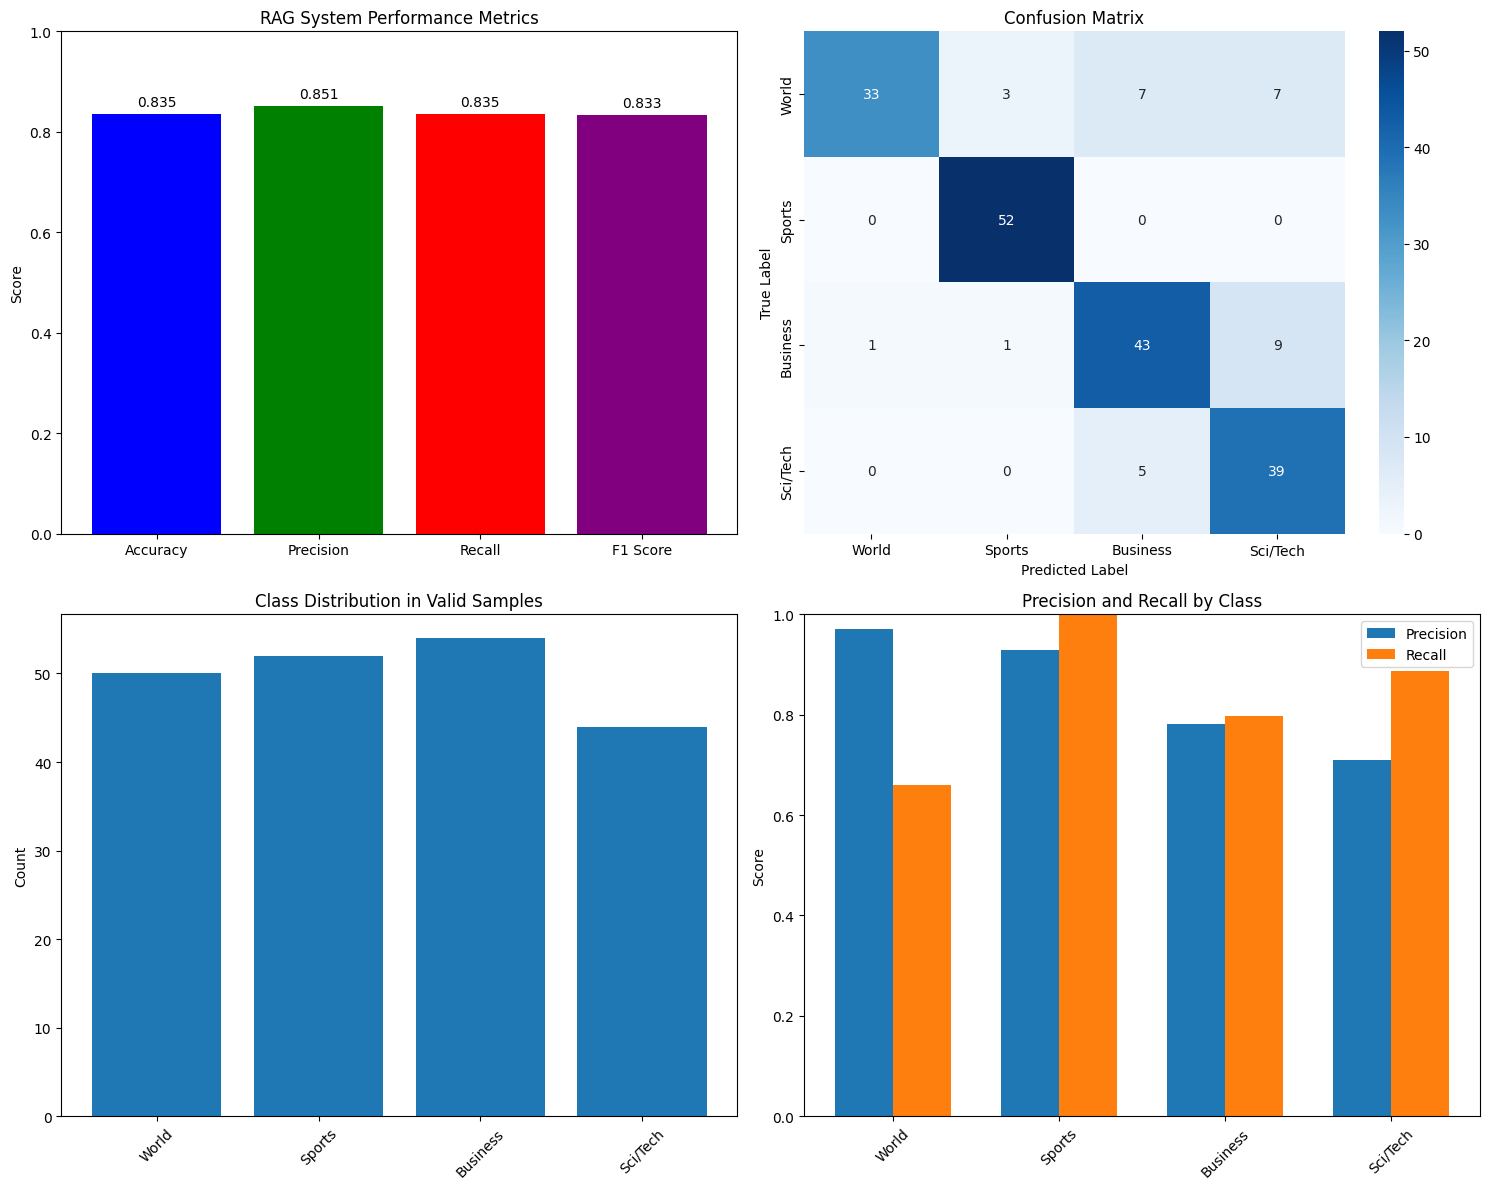

Performing advanced analysis...


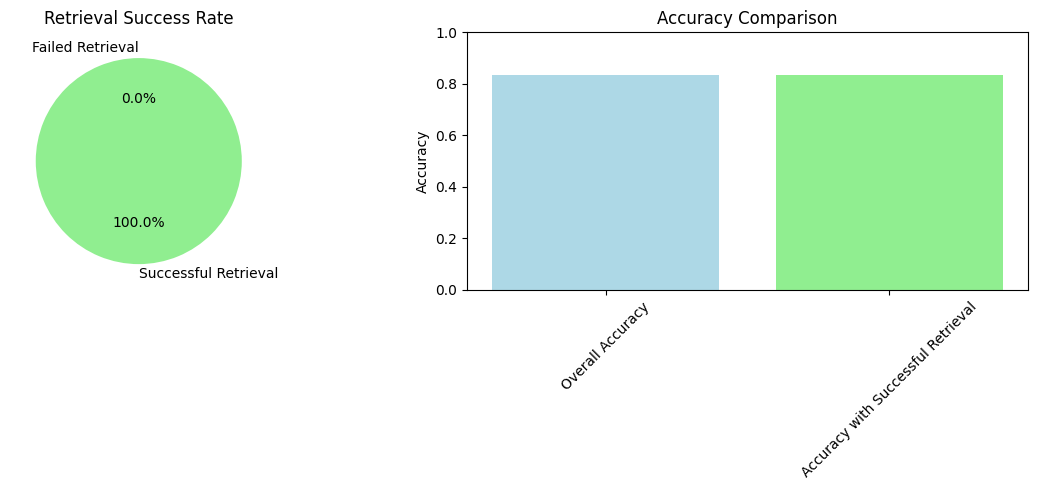

Retrieval Success Rate: 1.000
Accuracy with Successful Retrieval: 0.835

SAMPLE PREDICTIONS

Example 1:
Query: What category does this news belong to: Indian board plans own telecast of Australia series The Indi...
True Label: Sports
Predicted Label: Sports
Retrieved Labels: ['Sports', 'Sports', 'World']
Generated Response: has been seeking to set aside the cricket telecast rights given to it by the BCCI to set aside the cricket series.

Zee Telefilms filed a writ petition in the Supreme Court seeking quashing of BCCI #39;s

Example 2:
Query: What category does this news belong to: Stocks Higher on Drop in Jobless Claims A sharp drop in init...
True Label: Business
Predicted Label: Business
Retrieved Labels: ['Business', 'World', 'Business']
Generated Response: less Claims?

Example 3:
Query: What category does this news belong to: Nuggets 112, Raptors 106 Carmelo Anthony scored 30 points an...
True Label: Sports
Predicted Label: Sports
Retrieved Labels: ['Sports', 'Sports', 'Sports']


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, pipeline
from sentence_transformers import SentenceTransformer
import faiss
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import json
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

class RAGSystem:
    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2",
                 generator_model="gpt2"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        # Initialize embedding model
        self.embedding_model = SentenceTransformer(model_name)

        # Initialize generator model
        self.tokenizer = AutoTokenizer.from_pretrained(generator_model)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.generator = pipeline(
            "text-generation",
            model=generator_model,
            tokenizer=self.tokenizer,
            device=0 if torch.cuda.is_available() else -1,
            max_new_tokens=50
        )

        # Initialize FAISS index
        self.dimension = self.embedding_model.get_sentence_embedding_dimension()
        self.index = faiss.IndexFlatL2(self.dimension)
        self.corpus = []
        self.metadata = []

    def create_embeddings(self, texts: List[str]) -> np.ndarray:
        """Create embeddings for given texts"""
        return self.embedding_model.encode(texts, convert_to_tensor=False)

    def build_index(self, dataset, sample_size=5000):
        """Build FAISS index from dataset"""
        print("Building FAISS index...")

        # Sample the dataset
        sampled_data = dataset.shuffle(seed=42).select(range(min(sample_size, len(dataset))))

        texts = []
        labels = []

        for item in tqdm(sampled_data, desc="Processing samples"):
            # AG News has 'text' field
            text = item['text']
            texts.append(text)
            labels.append(item['label'])
            self.corpus.append(text)
            self.metadata.append({'label': item['label'], 'text': text})

        # Create embeddings
        embeddings = self.create_embeddings(texts)

        # Add to FAISS index
        self.index.add(embeddings.astype('float32'))

        print(f"Index built with {len(self.corpus)} documents")
        return embeddings, labels

    def retrieve(self, query: str, k: int = 3) -> List[Dict]:
        """Retrieve top-k most relevant documents"""
        query_embedding = self.create_embeddings([query])
        distances, indices = self.index.search(query_embedding.astype('float32'), k)

        results = []
        for i, idx in enumerate(indices[0]):
            if idx < len(self.corpus) and idx >= 0:
                results.append({
                    'text': self.corpus[idx],
                    'metadata': self.metadata[idx],
                    'distance': distances[0][i]
                })

        return results

    def generate_response(self, query: str, context: str) -> str:
        """Generate response using retrieved context"""
        prompt = f"""Based on the following context, answer the question.

Context: {context}

Question: {query}

Answer:"""

        try:
            response = self.generator(
                prompt,
                max_length=len(prompt.split()) + 20,
                num_return_sequences=1,
                temperature=0.1,
                do_sample=False
            )
            return response[0]['generated_text'].split("Answer:")[-1].strip()
        except:
            return "I cannot answer this question based on the available information."

    def rag_pipeline(self, query: str, k: int = 3) -> Dict:
        """Complete RAG pipeline"""
        # Retrieve relevant documents
        retrieved_docs = self.retrieve(query, k)

        # Combine context
        context = "\n".join([doc['text'] for doc in retrieved_docs])

        # Generate response
        response = self.generate_response(query, context)

        return {
            'query': query,
            'retrieved_docs': retrieved_docs,
            'context': context,
            'response': response
        }

def load_ag_news_dataset():
    """Load and prepare AG News dataset"""
    print("Loading AG News dataset...")
    dataset = load_dataset("ag_news")

    # Map label indices to class names
    class_names = {
        0: "World",
        1: "Sports",
        2: "Business",
        3: "Sci/Tech"
    }

    # Add class names to dataset
    def add_class_name(example):
        example['class_name'] = class_names[example['label']]
        return example

    dataset = dataset.map(add_class_name)

    print(f"Dataset loaded: {len(dataset['train'])} training, {len(dataset['test'])} test samples")
    print(f"Sample data: {dataset['train'][0]}")
    return dataset, class_names

def evaluate_rag_system(rag_system, test_data, num_samples=100):
    """Evaluate RAG system performance"""
    print("Evaluating RAG system...")

    # Sample test data
    test_samples = test_data.shuffle(seed=42).select(range(min(num_samples, len(test_data))))

    results = []
    predictions = []
    true_labels = []

    for i, sample in tqdm(enumerate(test_samples), total=len(test_samples), desc="Evaluating"):
        query = f"What category does this news belong to: {sample['text']}"
        true_label = sample['label']

        result = rag_system.rag_pipeline(query)

        # Simple classification based on retrieved documents
        retrieved_labels = [doc['metadata']['label'] for doc in result['retrieved_docs']]
        if retrieved_labels:
            pred_label = max(set(retrieved_labels), key=retrieved_labels.count)
        else:
            pred_label = -1

        results.append({
            'true_label': true_label,
            'pred_label': pred_label,
            'query': query,
            'response': result['response'],
            'retrieved_labels': retrieved_labels
        })

        predictions.append(pred_label)
        true_labels.append(true_label)

    return results, predictions, true_labels

def calculate_metrics(true_labels, predictions, class_names):
    """Calculate evaluation metrics"""
    # Filter out invalid predictions
    valid_indices = [i for i, pred in enumerate(predictions) if pred != -1]
    valid_true = [true_labels[i] for i in valid_indices]
    valid_pred = [predictions[i] for i in valid_indices]

    if len(valid_true) > 0:
        accuracy = accuracy_score(valid_true, valid_pred)
        precision = precision_score(valid_true, valid_pred, average='weighted', zero_division=0)
        recall = recall_score(valid_true, valid_pred, average='weighted', zero_division=0)
        f1 = f1_score(valid_true, valid_pred, average='weighted', zero_division=0)

        # Confusion matrix
        cm = confusion_matrix(valid_true, valid_pred)

        # Class-wise metrics
        try:
            class_precision = precision_score(valid_true, valid_pred, average=None, zero_division=0)
            class_recall = recall_score(valid_true, valid_pred, average=None, zero_division=0)
            class_metrics = {
                i: {'precision': class_precision[i], 'recall': class_recall[i]}
                for i in range(len(class_names))
            }
        except:
            class_metrics = {}
    else:
        accuracy = precision = recall = f1 = 0.0
        cm = np.zeros((len(class_names), len(class_names)))
        class_metrics = {}

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'samples_evaluated': len(valid_true),
        'total_samples': len(true_labels),
        'class_metrics': class_metrics
    }

    return metrics, cm, valid_true, valid_pred

def plot_metrics(metrics, class_names, cm, valid_true, valid_pred):
    """Plot evaluation metrics and results"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Bar plot for metrics
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    metric_values = [metrics['accuracy'], metrics['precision'], metrics['recall'], metrics['f1_score']]

    axes[0, 0].bar(metric_names, metric_values, color=['blue', 'green', 'red', 'purple'])
    axes[0, 0].set_title('RAG System Performance Metrics')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_ylim(0, 1)
    for i, v in enumerate(metric_values):
        axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names.values(),
                yticklabels=class_names.values(),
                ax=axes[0, 1])
    axes[0, 1].set_title('Confusion Matrix')
    axes[0, 1].set_xlabel('Predicted Label')
    axes[0, 1].set_ylabel('True Label')

    # Sample distribution
    class_distribution = {name: 0 for name in class_names.values()}
    for label in valid_true:
        if label in class_names:
            class_distribution[class_names[label]] += 1

    axes[1, 0].bar(class_distribution.keys(), class_distribution.values())
    axes[1, 0].set_title('Class Distribution in Valid Samples')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Precision-Recall by class
    if metrics['class_metrics'] and len(metrics['class_metrics']) > 1:
        class_precision = [metrics['class_metrics'][i]['precision'] for i in range(len(class_names))]
        class_recall = [metrics['class_metrics'][i]['recall'] for i in range(len(class_names))]

        x = np.arange(len(class_names))
        width = 0.35

        axes[1, 1].bar(x - width/2, class_precision, width, label='Precision')
        axes[1, 1].bar(x + width/2, class_recall, width, label='Recall')
        axes[1, 1].set_title('Precision and Recall by Class')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(class_names.values(), rotation=45)
        axes[1, 1].legend()
        axes[1, 1].set_ylim(0, 1)
    else:
        axes[1, 1].text(0.5, 0.5, 'Not enough data for class-wise metrics',
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Precision and Recall by Class')

    plt.tight_layout()
    plt.savefig('rag_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

def advanced_analysis(results, class_names, metrics):
    """Perform advanced analysis of RAG results"""

    # Calculate retrieval quality
    retrieval_success = []
    for result in results:
        if result['retrieved_labels']:
            retrieval_success.append(1)
        else:
            retrieval_success.append(0)

    retrieval_rate = sum(retrieval_success) / len(retrieval_success) if retrieval_success else 0

    # Calculate accuracy when retrieval is successful
    successful_retrieval = [r for r in results if r['retrieved_labels']]
    successful_true = [r['true_label'] for r in successful_retrieval]
    successful_pred = [r['pred_label'] for r in successful_retrieval]

    if successful_true and len(successful_true) > 0:
        successful_accuracy = accuracy_score(successful_true, successful_pred)
    else:
        successful_accuracy = 0

    # Plot retrieval analysis
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Retrieval success rate
    labels = ['Successful Retrieval', 'Failed Retrieval']
    sizes = [retrieval_rate, max(0, 1 - retrieval_rate)]  # Ensure non-negative
    colors = ['lightgreen', 'lightcoral']

    axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Retrieval Success Rate')

    # Accuracy comparison
    comparison_data = {
        'Overall Accuracy': metrics['accuracy'],
        'Accuracy with Successful Retrieval': successful_accuracy
    }

    axes[1].bar(comparison_data.keys(), comparison_data.values(), color=['lightblue', 'lightgreen'])
    axes[1].set_title('Accuracy Comparison')
    axes[1].set_ylabel('Accuracy')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig('retrieval_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'retrieval_rate': retrieval_rate,
        'successful_retrieval_accuracy': successful_accuracy
    }

def main():
    """Main function to run the RAG system"""
    # Load dataset
    dataset, class_names = load_ag_news_dataset()

    # Initialize RAG system
    rag_system = RAGSystem()

    # Build index with training data
    print("Building index...")
    embeddings, labels = rag_system.build_index(dataset['train'], sample_size=10000)

    # Evaluate on test data
    print("Evaluating system...")
    results, predictions, true_labels = evaluate_rag_system(
        rag_system, dataset['test'], num_samples=200
    )

    # Calculate metrics
    print("Calculating metrics...")
    metrics, cm, valid_true, valid_pred = calculate_metrics(true_labels, predictions, class_names)

    print("\n" + "="*50)
    print("RAG SYSTEM EVALUATION RESULTS")
    print("="*50)
    print(f"Accuracy: {metrics['accuracy']:.3f}")
    print(f"Precision: {metrics['precision']:.3f}")
    print(f"Recall: {metrics['recall']:.3f}")
    print(f"F1 Score: {metrics['f1_score']:.3f}")
    print(f"Samples evaluated: {metrics['samples_evaluated']}/{metrics['total_samples']}")

    # Plot metrics
    print("Generating plots...")
    plot_metrics(metrics, class_names, cm, valid_true, valid_pred)

    # Advanced analysis
    print("Performing advanced analysis...")
    advanced_metrics = advanced_analysis(results, class_names, metrics)
    print(f"Retrieval Success Rate: {advanced_metrics['retrieval_rate']:.3f}")
    print(f"Accuracy with Successful Retrieval: {advanced_metrics['successful_retrieval_accuracy']:.3f}")

    # Save results
    with open('rag_results.json', 'w') as f:
        json.dump({
            'metrics': metrics,
            'advanced_metrics': advanced_metrics,
            'results': results[:10],  # Save first 10 examples
            'class_names': class_names
        }, f, indent=2)

    # Show some examples
    print("\n" + "="*50)
    print("SAMPLE PREDICTIONS")
    print("="*50)
    for i, result in enumerate(results[:3]):
        print(f"\nExample {i+1}:")
        print(f"Query: {result['query'][:100]}...")
        print(f"True Label: {class_names[result['true_label']]}")
        print(f"Predicted Label: {class_names[result['pred_label']] if result['pred_label'] != -1 else 'Unknown'}")
        print(f"Retrieved Labels: {[class_names[l] for l in result['retrieved_labels']] if result['retrieved_labels'] else 'None'}")
        print(f"Generated Response: {result['response']}")

    return rag_system, metrics, results

# Run the main function
if __name__ == "__main__":
    rag_system, metrics, results = main()